## Data Preparation

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-04-21 12:52:29--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  4.05MB/s    in 0.3s    

2026-04-21 12:52:30 (4.05 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [6]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [7]:
series_index = list(df.dtypes[df.dtypes == 'str'].index)
series_index

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [8]:
for col in series_index:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [10]:
df.dtypes.index

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

## Exploratory Data Analysis (EDA)

In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5, ])
    print(df[col].nunique())
    print()
    

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# for ensure all plots can be displayed in the notebook
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

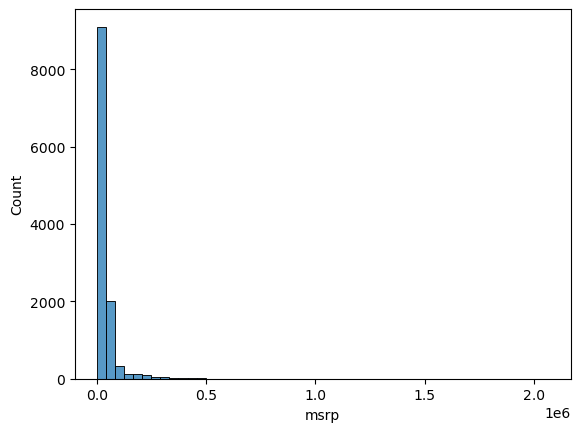

In [14]:
sns.histplot(df.msrp, bins=50)

# bins how many bars

<Axes: xlabel='msrp', ylabel='Count'>

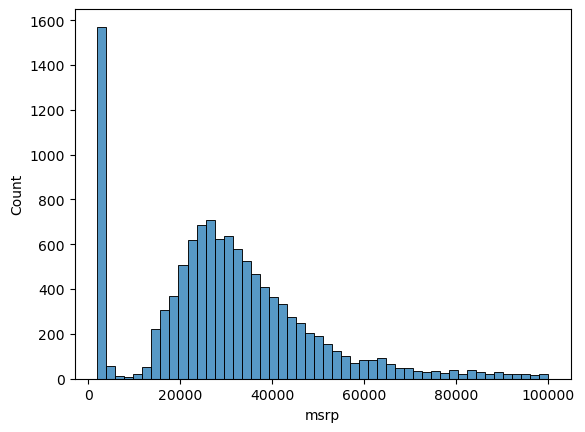

In [15]:
sns.histplot(df.msrp[df.msrp < 100_000], bins=50)

In [16]:
# using logarithmic to squashing the values (rid of the long range between values)

np.log(np.array([0, 1, 10,  1000, 1000000]) + 1)
# or using 
np.log1p([0, 1, 10,  1000, 1000000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 13.81551156])

In [17]:
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

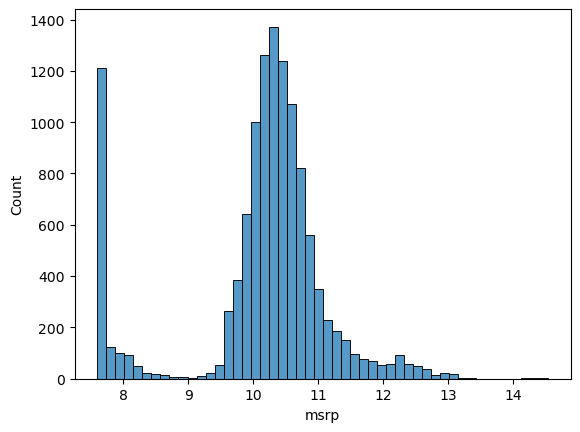

In [18]:
sns.histplot(price_logs, bins=50)

# now it's like normal distribution, so it's good for the model (best
# than long tail distribution)

##### Missing values

In [19]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up The Validation framework

In [20]:
n = len(df)

n_validation = int(n * 0.2)
n_test = int(n * 0.2) 
n_train = n - (n_test + n_validation)

n, n_validation + n_test + n_train

(11914, 11914)

In [21]:
df_train = df.iloc[ : n_train]

df_validation = df.iloc[n_train : n_train + n_validation]
df_test = df.iloc[n_train + n_validation : ]

In [22]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [23]:
# for shuffle the records
idx = np.arange(len(df))

np.random.seed(42)
np.random.shuffle(idx)

df_train = df.iloc[idx[ : n_train]]
df_validation = df.iloc[ idx[n_train : n_train + n_validation]]
df_test = df.iloc[ idx[n_train + n_validation : ]]

In [24]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
3995,gmc,envoy_xl,2005,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,18,13,549,29695
7474,volkswagen,passat,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,38,25,873,30495
7300,honda,odyssey,2016,regular_unleaded,248.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,28,19,2202,37650
3148,chevrolet,cruze,2015,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,NaN,midsize,sedan,36,25,1385,16170
747,volvo,740,1991,regular_unleaded,162.0,4.0,automatic,rear_wheel_drive,4.0,"luxury,performance",midsize,sedan,20,17,870,2000


In [25]:
df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,gmc,envoy_xl,2005,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,18,13,549,29695
1,volkswagen,passat,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,38,25,873,30495
2,honda,odyssey,2016,regular_unleaded,248.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,28,19,2202,37650
3,chevrolet,cruze,2015,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,NaN,midsize,sedan,36,25,1385,16170
4,volvo,740,1991,regular_unleaded,162.0,4.0,automatic,rear_wheel_drive,4.0,"luxury,performance",midsize,sedan,20,17,870,2000


In [26]:
# get target values

y_train = np.log1p(df_train.msrp.values)
y_validation = np.log1p(df_validation.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [27]:
del df_train['msrp']
del df_validation['msrp']
del df_test['msrp']

## 2.5 Linear Regression

In [28]:
df_train.iloc[4]

make                              volvo
model                               740
year                               1991
engine_fuel_type       regular_unleaded
engine_hp                         162.0
engine_cylinders                    4.0
transmission_type             automatic
driven_wheels          rear_wheel_drive
number_of_doors                     4.0
market_category      luxury,performance
vehicle_size                    midsize
vehicle_style                     sedan
highway_mpg                          20
city_mpg                             17
popularity                          870
Name: 4, dtype: object

In [29]:
w0 = 7.7 # bias
ws = [0.01, 0.04, 0.001]

In [30]:
def get_data(xi):
    
    data = []
    data.append(df_train.iloc[xi]['engine_hp'])
    data.append(df_train.iloc[xi]['city_mpg'])
    data.append(df_train.iloc[xi]['popularity'])

    return data

def linear_regression(xi):

    result = w0
    for term in range(len(xi)):
       result += ws[term] * xi[term] 

    return result

In [31]:
linear_regression(get_data(4))

np.float64(10.87)

In [32]:
# to back target value to original value (use e to rid of log)
# np.exp(10.87) - 1 or:

np.expm1(10.87)

np.float64(52574.21027040534)

In [33]:
np.log1p(52574.21027040534)

np.float64(10.87)

## 2.6 Linear regression (vector form)

In [34]:
def dot(xi, ws):

    n = len(xi)
    result = 0.0

    for i in range(n):
        result += xi[i] * ws[i]

    return result

In [35]:
"""
w0 = 7.7 # bias
ws = [0.01, 0.04, 0.001]


def linear_regression(xi):
    return w0 + dot(xi, ws)


ws = [w0] + ws

def linear_regression(xi):
    xi = [1] + x1
    return dot(xi, ws)

"""
print()

In [36]:
w0 = 7.7 # bias

ws = [0.01, 0.04, 0.001]
ws = [w0] + ws

In [37]:
# 3 cars

X = [
    [1,148,24,1358],
    [1,108,23,2358],
    [1,448,14,58]
]
X = np.array(X)
X

array([[   1,  148,   24, 1358],
       [   1,  108,   23, 2358],
       [   1,  448,   14,   58]])

In [38]:
def linear_regression(X):
    return X.dot(ws)

In [39]:
linear_regression(X)

array([11.498, 12.058, 12.798])

## 2.7 Training a linear regression model (Normal Equation)

In [69]:
X =[
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 83],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86],  
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   83],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [70]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])

In [73]:
# by using (gram matrix) cuz maybe the matrix does not have inverse, so to get w = (X^T X)^-1 X^T y

X # X
XT = X.T # X^T
XTX = XT.dot(X) # X^T X
XTX_inv = np.linalg.inv(XTX) # (X^T X)^-1

XTX_inv_XT = XTX_inv.dot(XT) # (X^T X)^-1 X^T 
print(XTX_inv_XT) # not exactly identity matrix, but the values are super small 

[[ 1.01706159e-01 -3.00739115e-01  1.21393812e-01  8.40324519e-01
   6.92114387e-01  3.39196656e-01 -3.75360929e-01  7.02070483e-01
  -1.12070597e+00]
 [-1.57955783e-04  4.52044589e-04  7.09101535e-04 -1.35027155e-03
  -1.08990115e-03  2.59238292e-04 -8.98910635e-05 -1.17492671e-03
   2.44256185e-03]
 [-2.33983550e-03  3.26841763e-03 -6.03000493e-03 -1.17522723e-02
  -8.94039142e-03 -9.52262347e-03  2.16890602e-02 -9.57040821e-03
   2.31980580e-02]
 [ 2.04565692e-04  4.28323120e-04 -4.30426513e-05 -2.16600756e-04
  -1.87061402e-04 -8.75882867e-05 -9.00182410e-05 -1.36854273e-04
   1.28276799e-04]]


In [82]:
y = [10000, 20000, 15000, 25000, 10000, 20000, 15000, 25000, 12000]

w = XTX_inv_XT.dot(y)

w0 = w[0]
w = w[1:]

w0, w

(np.float64(30009.25292276671),
 array([ -22.78396914, -257.69087426,   -2.30322797]))

In [83]:
def train_linear_regression(X, y):

    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XT = X.T # X^T
    XTX = XT.dot(X) # X^T X
    XTX_inv = np.linalg.inv(XTX) # (X^T X)^-1
    XTX_inv_XT = XTX_inv.dot(XT) # (X^T X)^-1 X^T 
    
    w = XTX_inv_XT.dot(y)

    return w[0], w[1:]

In [84]:
train_linear_regression(X,y)

(np.float64(1.1803887523479435e+21),
 array([-1.18038875e+21,  2.65523467e+01,  2.45817993e-12, -6.94661137e+01]))

## 2.8 Car price baseline model

In [85]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,gmc,envoy_xl,2005,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,4.0,NaN,large,4dr_suv,18,13,549
1,volkswagen,passat,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,38,25,873
2,honda,odyssey,2016,regular_unleaded,248.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,28,19,2202
3,chevrolet,cruze,2015,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,NaN,midsize,sedan,36,25,1385
4,volvo,740,1991,regular_unleaded,162.0,4.0,automatic,rear_wheel_drive,4.0,"luxury,performance",midsize,sedan,20,17,870


In [87]:
# get all numerical values

base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
df_train[base].head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,275.0,6.0,18,13,549
1,170.0,4.0,38,25,873
2,248.0,6.0,28,19,2202
3,138.0,4.0,36,25,1385
4,162.0,4.0,20,17,870


In [97]:
X_train = df_train[base].values
y_train 

array([10.29876764, 10.32535081, 10.53611479, ...,  9.83258214,
        9.96062374, 10.28537692], shape=(7150,))

In [104]:
df_train[base].isnull().sum()

engine_hp           52
engine_cylinders    16
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [120]:
X_train = df_train[base].fillna(0).values

In [121]:
w0, w = train_linear_regression(X_train, y_train)

In [122]:
y_predict = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

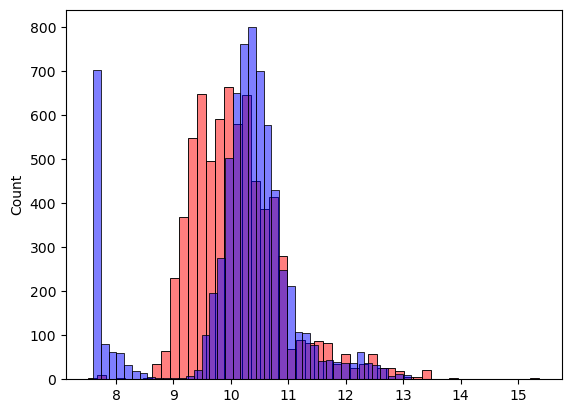

In [123]:
sns.histplot(y_predict, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)